# Radiomics

**What is Radiomics?**
- Is a process of extracting a large set of quantitative features and analyses their statistical correlation with observable aspects of the disease (e.g., physiological parameters) to identify those of most relevance.

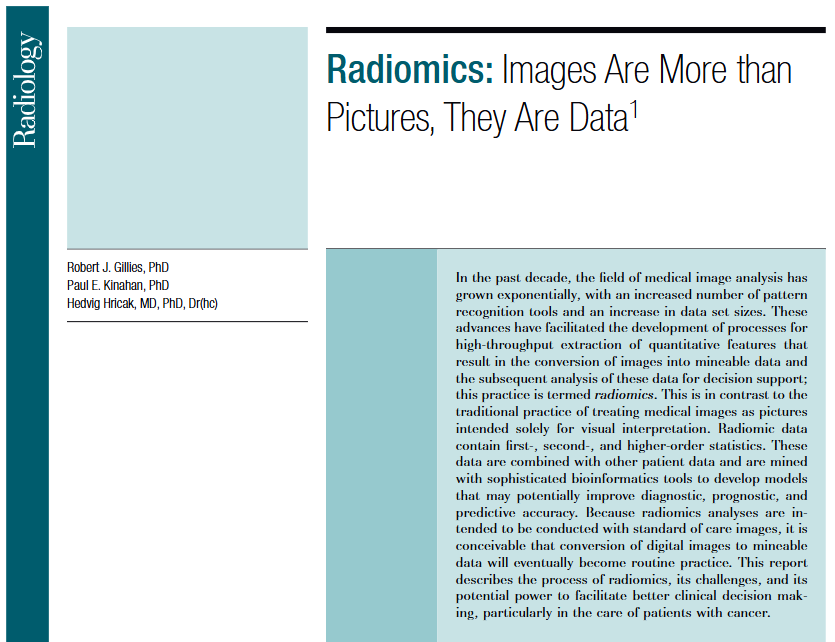

Radiomics papers: 
- https://doi.org/10.1148/radiol.2015151169
- https://www.sciencedirect.com/science/article/abs/pii/S0959804911009993

**What is IPF?**
- Idiopathic pulmonary fibrosis (IPF) is a chronic disease characterized by an irreversible decline in lung function.

Radiomics in IPF:
- https://www.sciencedirect.com/science/article/pii/S2772652522000175
- https://www.mdpi.com/2075-4418/12/4/1002
- https://www.mdpi.com/2075-4418/10/5/306

To extract radiomics features, we will be using a package called Pyradiomics. Read more here: https://pyradiomics.readthedocs.io/en/latest/features.html and https://aim.mgh.harvard.edu/pyradiomics.

Check out the work by my former student yashodhar for inspiration: https://github.com/YashodharPansuriya/Radiomics-Analysis-and-ML-for-Prognostic-Biomarkers-in-IPF

In [2]:
# Radiomics package
from __future__ import annotations

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import SimpleITK as sitk
import ipywidgets as widgets
from ipywidgets import interact
from radiomics import featureextractor
# Display the images
%matplotlib inline
import matplotlib.pyplot as plt

# read in our Nifti and corresponding mask

In [ ]:
# ============================================================
# ✅ Resampling utilities (same as your pipeline)
# ============================================================
def resample_volume(ct_array, original_spacing, new_spacing=(1, 1, 1), interpolator=sitk.sitkBSpline):
    """
    Resample a 3D numpy CT volume to new spacing (default 1mm isotropic).
    original_spacing and new_spacing must be in (z, y, x) order.
    """
    image_itk = sitk.GetImageFromArray(ct_array)

    # SimpleITK expects spacing in (x, y, z)
    image_itk.SetSpacing(tuple(float(s) for s in original_spacing[::-1]))

    original_size = np.array(image_itk.GetSize(), dtype=np.int32)
    original_spacing_np = np.array(original_spacing, dtype=np.float64)
    new_spacing_np = np.array(new_spacing, dtype=np.float64)

    # Compute new size
    new_size = np.round(original_size * (original_spacing_np[::-1] / new_spacing_np[::-1])).astype(int)

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(tuple(float(s) for s in new_spacing_np[::-1]))
    resampler.SetSize([int(s) for s in new_size])
    resampler.SetOutputDirection(image_itk.GetDirection())
    resampler.SetOutputOrigin(image_itk.GetOrigin())
    resampler.SetInterpolator(interpolator)

    resampled_itk = resampler.Execute(image_itk)
    resampled_array = sitk.GetArrayFromImage(resampled_itk)

    # Convert spacing back to (z, y, x)
    actual_spacing = resampled_itk.GetSpacing()[::-1]

    return resampled_array, actual_spacing


def get_spacing_from_nifti(nii):
    """Return spacing in (z, y, x) order."""
    zooms = nii.header.get_zooms()[:3]  # (x, y, z)
    return (zooms[2], zooms[1], zooms[0])


# ============================================================
# ✅ Load CT and Mask
# ============================================================
nifti_path = "./Dataset/Nifti/ID00344637202287684217717.nii.gz"
mask_path  = "./Dataset/masks/ID00344637202287684217717_mask.nii.gz"

# Load CT
nii_ct = nib.load(nifti_path)
ct_array = nii_ct.get_fdata().astype(np.int16)
ct_spacing = get_spacing_from_nifti(nii_ct)

print(f"Original CT shape: {ct_array.shape}")
print("Original CT spacing:", ct_spacing)

# Load mask
nii_mask = nib.load(mask_path)
mask = nii_mask.get_fdata().astype(np.int16)
mask_spacing = get_spacing_from_nifti(nii_mask)

print(f"Original mask shape: {mask.shape}")
print("Original mask spacing:", mask_spacing)

# ============================================================
# ✅ Resample CT and Mask to 1mm isotropic
# ============================================================
new_spacing = (1, 1, 1)

resampled_ct, ct_new_spacing = resample_volume(ct_array, ct_spacing, new_spacing=new_spacing)
resampled_mask, mask_new_spacing = resample_volume(mask, mask_spacing, new_spacing=new_spacing, interpolator=sitk.sitkNearestNeighbor)

print("\n✅ After resampling:")
print("CT shape:", resampled_ct.shape, "spacing:", ct_new_spacing)
print("Mask shape:", resampled_mask.shape, "spacing:", mask_new_spacing)

# ============================================================
# ✅ Visualization function
# ============================================================
def show_slice(slice_idx):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # CT slice
    sns.heatmap(resampled_ct[slice_idx], cmap="gray", cbar=False, ax=axes[0])
    axes[0].set_title(f"Slice {slice_idx}")
    axes[0].axis("off")

    # Mask overlay
    sns.heatmap(resampled_ct[slice_idx], cmap="gray", cbar=False, ax=axes[1])
    sns.heatmap(resampled_mask[slice_idx], cmap="viridis", alpha=0.5, cbar=False, ax=axes[1])
    axes[1].set_title(f" Mask Overlay - Slice {slice_idx}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# plt.figure(figsize=(10,5))
# sns.kdeplot(ct_array.flatten(), label="Original", bw_adjust=0.5)
# sns.kdeplot(resampled_ct.flatten(), label="Resampled", bw_adjust=0.5)
# plt.legend()
# plt.title("Intensity Distribution Before vs After Resampling")
# plt.show()


# ============================================================
# ✅ Interactive slider
# ============================================================
# interact(show_slice, slice_idx=widgets.IntSlider(min=0, max=resampled_ct.shape[0]-1, step=1, value=resampled_ct.shape[0]//2));
show_slice(176)

npz keys: ['mask', 'spacing', 'origin', 'direction']
mask shape, dtype: (33, 512, 512) uint8


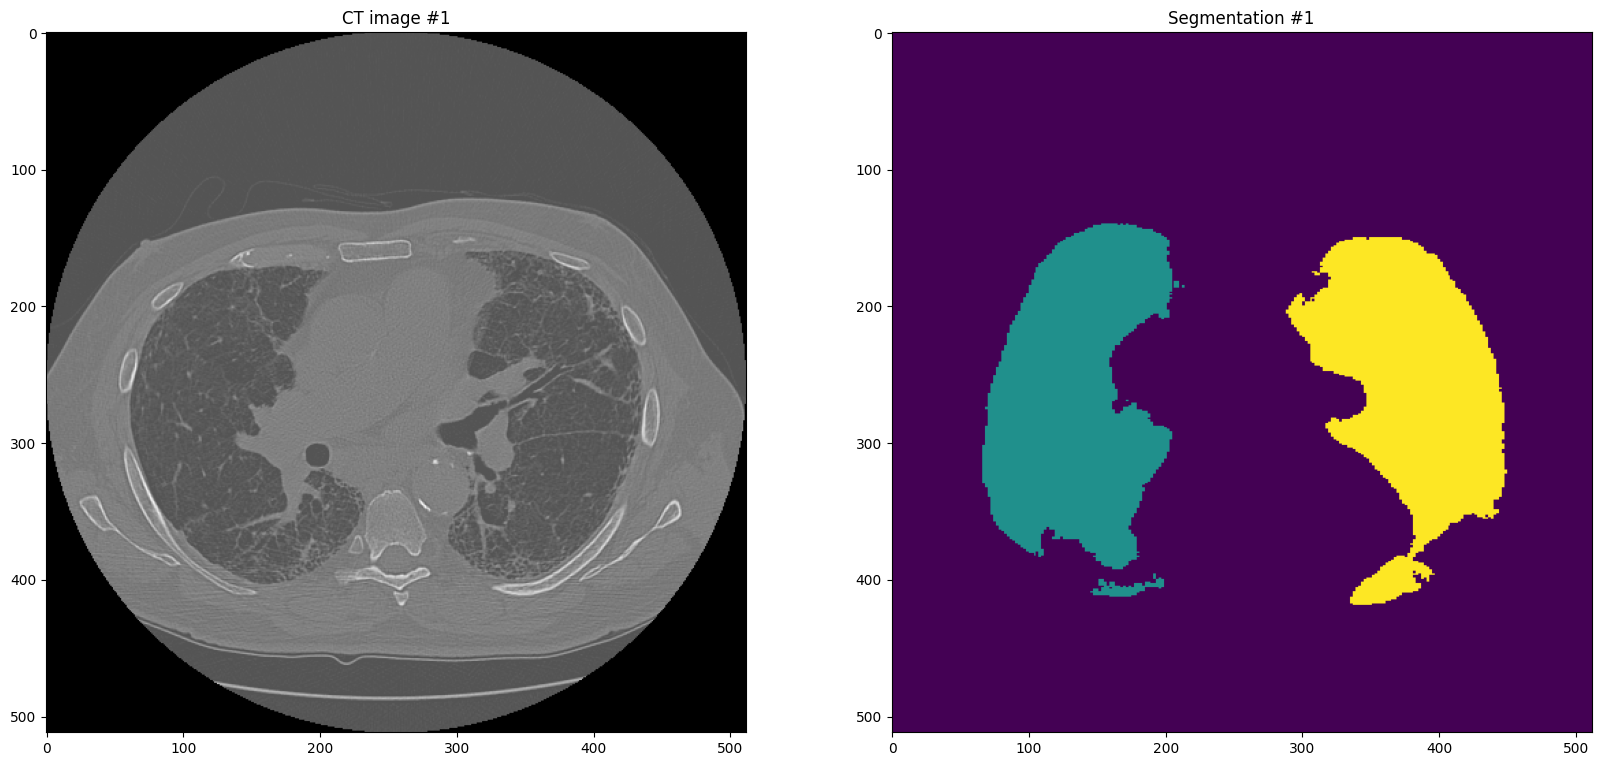

In [6]:
plt.figure(figsize=(20,20))
# First image
plt.subplot(2,2,1)
plt.imshow(sitk.GetArrayFromImage(image)[15,:,:], cmap="gray")
plt.title("CT image #1")
plt.subplot(2,2,2)
plt.imshow(mask_array[15,:,:])        
plt.title("Segmentation #1")

plt.show()

# For easier processing

1. We will convert dicom series into nifti file. Read more about nifti formats: https://nifti.nimh.nih.gov/background/

In [ ]:
pathNifti = './Dataset/Nifti/'

#Convnvert out dicom series to a single 3D image and save it as a .nii file
for i,patient in enumerate(list_of_patients):
    dicom2nifti.convert_directory(os.path.join(basepath, patient), pathNifti, compression=True, reorient=True)
    #dicom_names = reader.GetGDCMSeriesFileNames(os.path.join(basepath, patient))
    #reader.SetFileNames(dicom_names)
    #image = reader.Execute()
    #sitk.WriteImage(image, os.path.join(pathNifti, patient + ".nii"))

Slice increment not consistent through all slices
---------------------------------------------------------
[-174.8 -180.     6.5] [  0.   0. -10.]
[-174.8 -180.    26.5] [  0.   0. -20.]
Instance Number: 4
---------------------------------------------------------
Traceback (most recent call last):
  File "/home/amugongo/BDAS2026_Project5_Prognostic-biomarkers-in-Idiopathic-pulmonary-fibrosis/ctIPF/lib/python3.10/site-packages/dicom2nifti/convert_dir.py", line 86, in convert_directory
    convert_dicom.dicom_array_to_nifti(dicom_input, nifti_file, reorient)
  File "/home/amugongo/BDAS2026_Project5_Prognostic-biomarkers-in-Idiopathic-pulmonary-fibrosis/ctIPF/lib/python3.10/site-packages/dicom2nifti/convert_dicom.py", line 119, in dicom_array_to_nifti
    results = convert_generic.dicom_to_nifti(dicom_list, output_file)
  File "/home/amugongo/BDAS2026_Project5_Prognostic-biomarkers-in-Idiopathic-pulmonary-fibrosis/ctIPF/lib/python3.10/site-packages/dicom2nifti/convert_generic.py", line 2

In [13]:
#create mask for each patient and save it as a .nii file
list_patients_nii = os.listdir(pathNifti)
for i,patient in enumerate(list_patients_nii):
    patient_name = patient.split(".")[0]
    print(f"Creating mask for patient: {patient_name}")

Creating mask for patient: 22535077488357105609140655548407691890393
Creating mask for patient: 22592312649876864348410408187623763828346
Creating mask for patient: 225153115745212199856807558818725739427761


# Extract the features

To use the radiomics package, first construct an extractor object from the parameters set in Params.yaml. Then generate features.

In [ ]:
# Instantiate the extractor
params = os.path.join(os.getcwd(), 'Params.yaml')

extractor = featureextractor.RadiomicsFeatureExtractor(params)

In [8]:
#compute features
result_1 = extractor.execute(image, mask_array)

ValueError: Error reading mask Filepath or SimpleITK object